Part A – Gene Expression Analysis

a. Heatmap

Use the normalized gene expression dataset to plot a clustered heatmap of the top differentially expressed genes between HBR and UHR samples.
Label both genes and samples.
Use a color gradient (e.g., Blues) to indicate expression levels.



In [12]:
# Install seaborn if needed
!pip install seaborn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================
# 1. Load Your Normalized Counts
# ============================
# Example: if uploaded to Colab via "Files" panel
df = pd.read_csv("hbr_uhr_top_deg_normalized_counts.csv", index_col=0)

# If TSV:
# df = pd.read_csv("hbr_uhr_top_deg_normalized_counts.tsv", sep="\t", index_col=0)

print("Data loaded. Shape:", df.shape)
df.head()


Data loaded. Shape: (12, 6)


,HBR_1,HBR_2,HBR_3,UHR_1,UHR_2,UHR_3
SULT4A1,375.0,343.6,339.4,3.5,6.9,2.6
MPPED1,157.8,158.4,162.6,0.7,3.0,2.6
PRAME,0.0,0.0,0.0,568.9,467.3,519.2
IGLC2,0.0,0.0,0.0,488.6,498.0,457.5
IGLC3,0.0,0.0,0.0,809.7,313.8,688.0


<Figure size 1000x1200 with 0 Axes>

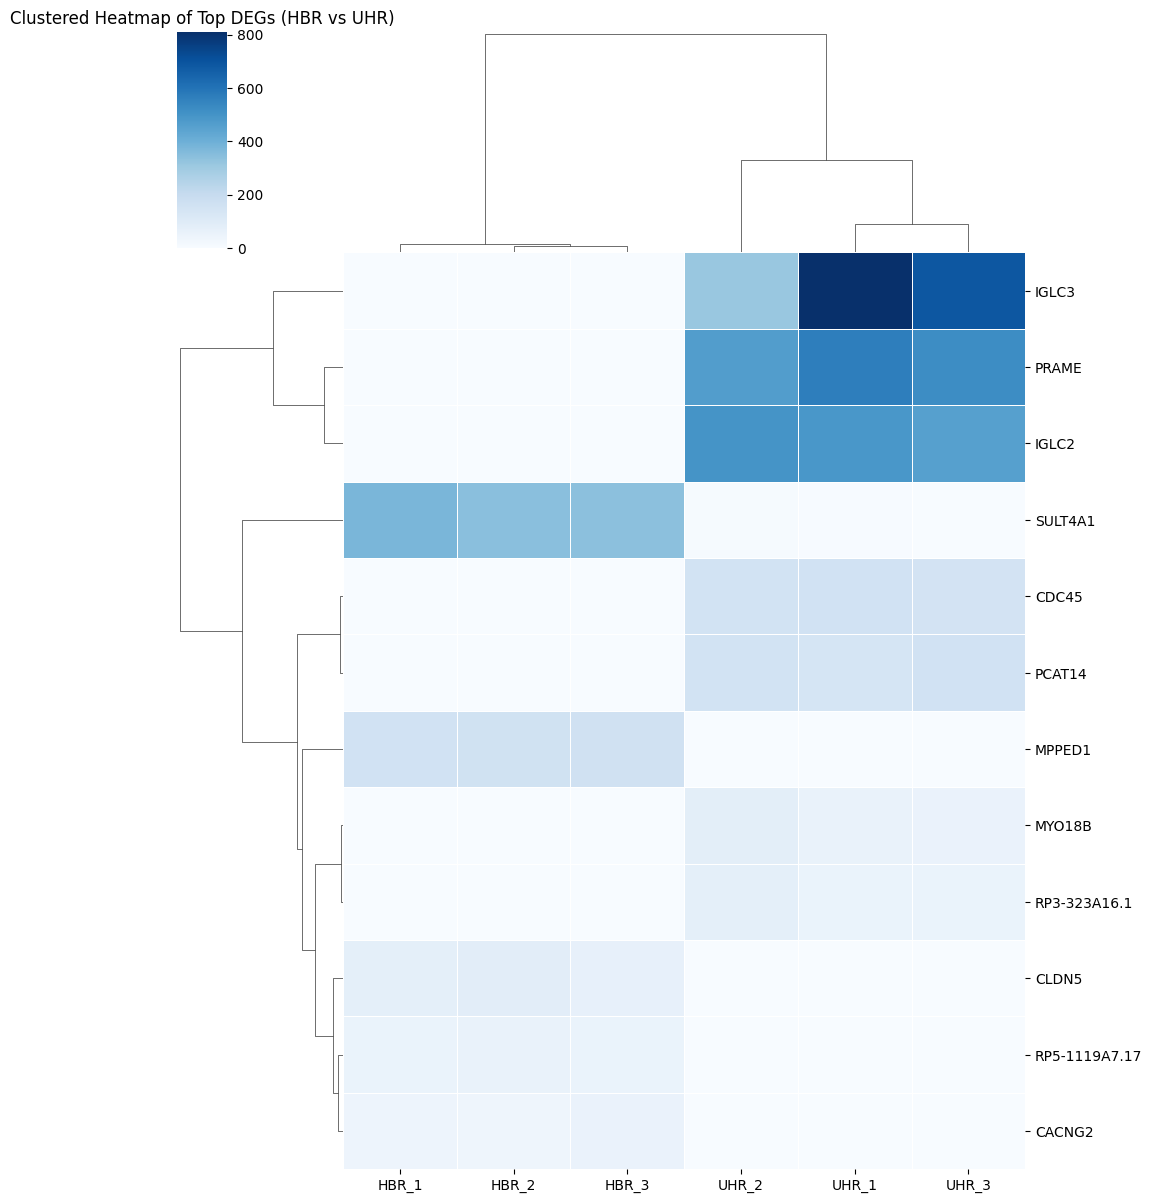

In [13]:
plt.figure(figsize=(10, 12))

sns.clustermap(
    df,
    cmap="Blues",          # color gradient
    linewidths=0.5,
    figsize=(10, 12),
    row_cluster=True,      # cluster genes
    col_cluster=True,      # cluster samples
)

plt.title("Clustered Heatmap of Top DEGs (HBR vs UHR)")
plt.show()


b. Volcano Plot

Plot log2FoldChange vs log10(Padj) from the DEG results.
Color points by significance:
Upregulated: green
Downregulated: orange
Not significant: grey
Add dashed vertical lines at log2FoldChange = ±1.

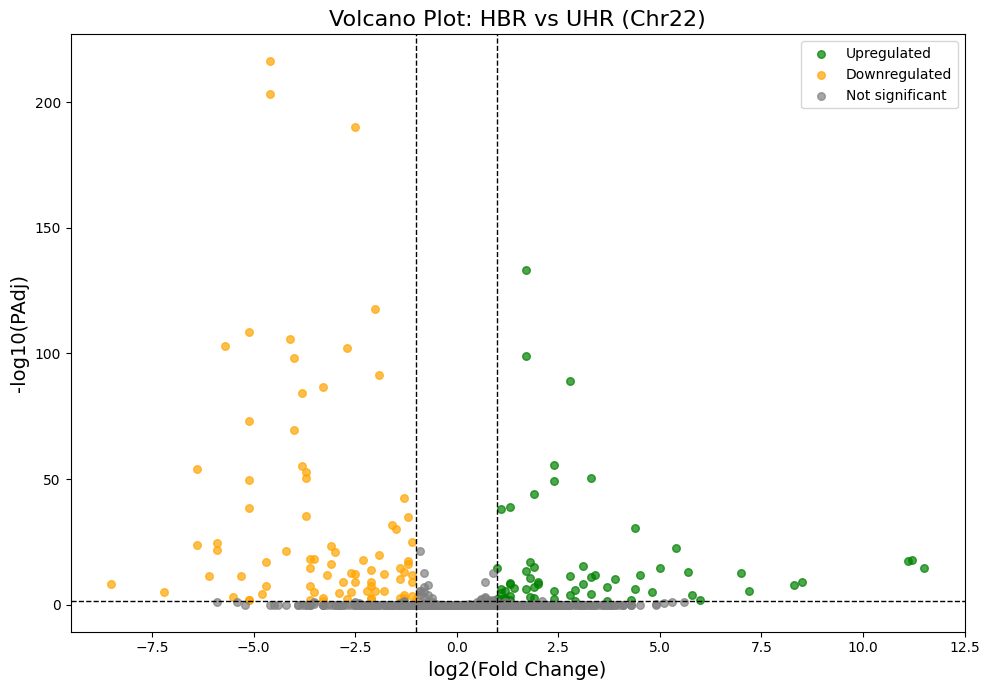

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your differential expression results
# Example: If uploaded to Colab as a CSV
hbr_uhr_deg_chr22_with_significance = pd.read_csv("hbr_uhr_deg_chr22_with_significance.csv")

df = hbr_uhr_deg_chr22_with_significance.copy()

# Replace zero or NA padj values (log10 undefined)
df['PAdj'] = df['PAdj'].replace(0, 1e-300)
df['PAdj'] = df['PAdj'].fillna(1.0)

# Compute -log10(padj)
df['-log10PAdj'] = -np.log10(df['PAdj'])

# Categorize gene significance
def get_category(row):
    if row['PAdj'] < 0.05:
        if row['log2FoldChange'] >= 1:
            return "Upregulated"
        elif row['log2FoldChange'] <= -1:
            return "Downregulated"
    return "Not significant"

df['category'] = df.apply(get_category, axis=1)

# Colors for categories
colors = {
    "Upregulated": "green",
    "Downregulated": "orange",
    "Not significant": "grey"
}

# Plot
plt.figure(figsize=(10, 7))
for category, color in colors.items():
    subset = df[df['category'] == category]
    plt.scatter(subset['log2FoldChange'],
                subset['-log10PAdj'],
                c=color,
                label=category,
                alpha=0.7,
                s=30)

# Add significance lines
plt.axvline(x=1, color='black', linestyle='--', linewidth=1)
plt.axvline(x=-1, color='black', linestyle='--', linewidth=1)
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=1)

# Labels and title
plt.xlabel('log2(Fold Change)', fontsize=14)
plt.ylabel('-log10(PAdj)', fontsize=14)
plt.title('Volcano Plot: HBR vs UHR (Chr22)', fontsize=16)

plt.legend()
plt.tight_layout()
plt.show()


Part B – Breast Cancer Data Exploration

c. Scatter Plot (radius vs texture)

Plot texture_mean vs radius_mean and color points by diagnosis (M = malignant, B = benign).

d. Correlation Heatmap

Compute the correlation matrix of six key features:

radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean.

Plot as a heatmap with correlation values annotated.

e. Scatter Plot (smoothness vs compactness)

Plot compactness_mean vs smoothness_mean colored by diagnosis.
Include gridlines and clear axis labels.

f. Density Plot (area distribution)

Plot kernel density estimates (KDE) of area_mean for both M and B diagnoses on the same axis.
Add legend and labeled axes.

In [15]:
import pandas as pd

df = pd.read_csv("data-3.csv")

df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


C. Scatter Plot – radius_mean vs texture_mean (colored by diagnosis)

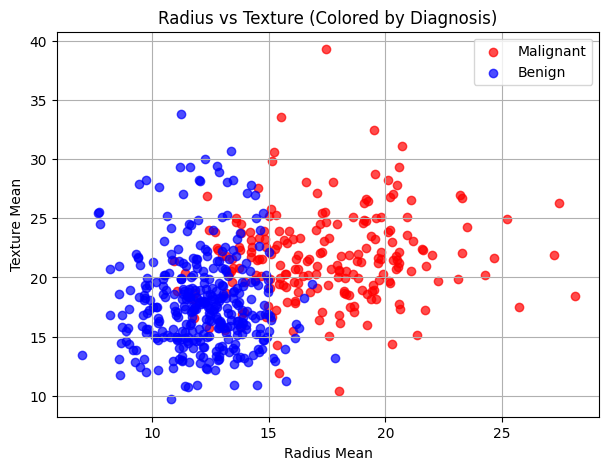

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

colors = {'M': 'red', 'B': 'blue'}

for diag in df['diagnosis'].unique():
    subset = df[df['diagnosis'] == diag]
    plt.scatter(subset['radius_mean'], subset['texture_mean'],
                c=colors[diag], label=('Malignant' if diag=='M' else 'Benign'),
                alpha=0.7)

plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.title("Radius vs Texture (Colored by Diagnosis)")
plt.legend()
plt.grid(True)
plt.show()


D. Correlation Heatmap – 6 Key Features


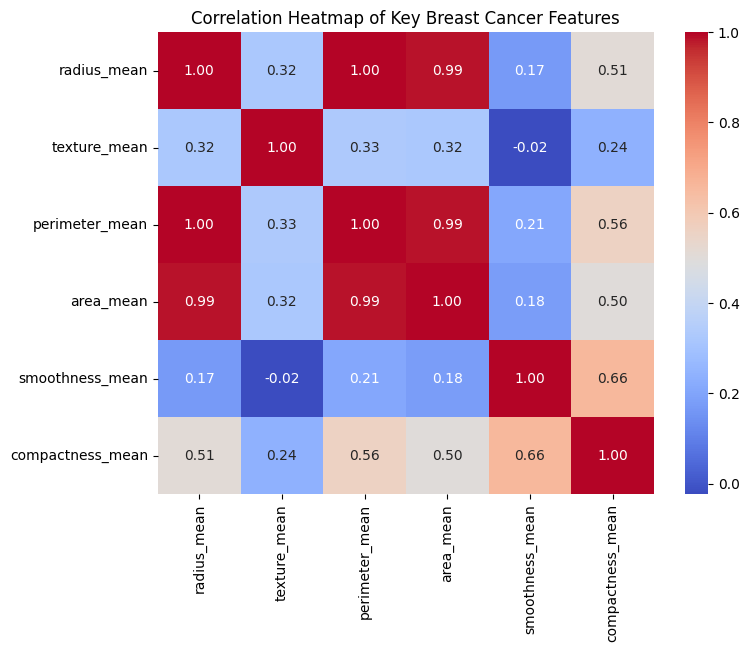

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean"
]

corr_matrix = df[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Breast Cancer Features")
plt.show()


E. Scatter Plot – smoothness_mean vs compactness_mean

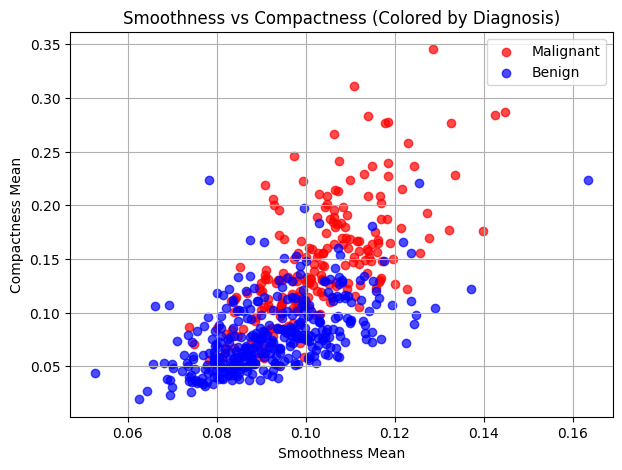

In [18]:
plt.figure(figsize=(7,5))

for diag in df['diagnosis'].unique():
    subset = df[df['diagnosis'] == diag]
    plt.scatter(subset['smoothness_mean'], subset['compactness_mean'],
                c=colors[diag], label=('Malignant' if diag=='M' else 'Benign'),
                alpha=0.7)

plt.xlabel("Smoothness Mean")
plt.ylabel("Compactness Mean")
plt.title("Smoothness vs Compactness (Colored by Diagnosis)")
plt.grid(True)
plt.legend()
plt.show()


F. Density Plot – area_mean distribution (M vs B)

/tmp/ipython-input-3445251847.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['diagnosis']=="M"]['area_mean'], label="Malignant", shade=True)
/tmp/ipython-input-3445251847.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['diagnosis']=="B"]['area_mean'], label="Benign", shade=True)


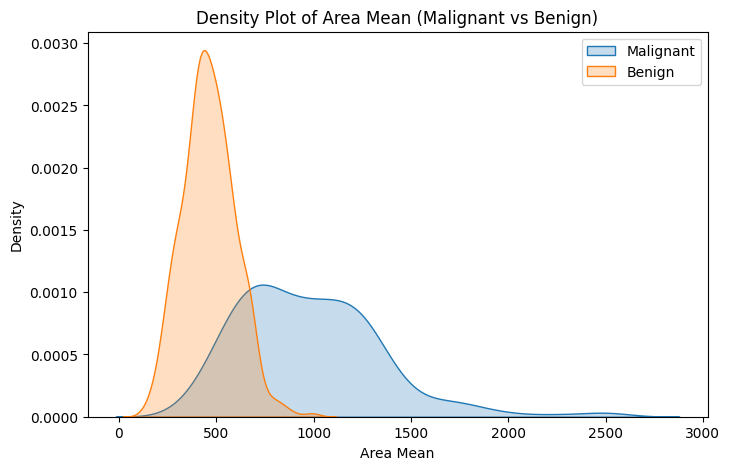

In [19]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.kdeplot(df[df['diagnosis']=="M"]['area_mean'], label="Malignant", shade=True)
sns.kdeplot(df[df['diagnosis']=="B"]['area_mean'], label="Benign", shade=True)

plt.xlabel("Area Mean")
plt.ylabel("Density")
plt.title("Density Plot of Area Mean (Malignant vs Benign)")
plt.legend()
plt.show()
